# Dark Matter indirect search analysis with Gammapy

This tutorial covers a whole pipeline analysis of indirect search of dark matter using Gammapy. 

we encourage to check tutorials XXXX and XXX for getting the basics about the Dark Matter module and how to handle data.

In this example we will make an analysis with simulated dat from the dwarf galaxy Draco follwing a 3D approach (using spatial and spectral data, not only spectral like in 1D analysis. For more details about the difference between 1D and 3D please go to tutotial XXX.)

Hence, the steps to follow in this tutorial are:
1. Data: Real Data or Simulated. In this ase will be the second option.
2. Run the executions.
3. Analysis products (profile likelihood limits, limits, brazilian plots)




*******rehacer********



#### What We Are Constraining

Depending on the DM model assumed, the constrained quantity is different.

---

**Dark matter annihilation**

The expected gamma-ray flux from DM annihilation is:

$$\Phi_{\rm ann} \propto \langle\sigma v\rangle \cdot J \cdot 
\int \frac{dN}{dE}\,dE$$

The physical quantity of interest is the **velocity-averaged annihilation 
cross section** ⟨σv⟩. A larger ⟨σv⟩ means a brighter signal. A 
non-detection gives an **upper limit** on ⟨σv⟩: the DM particles 
annihilate *at most* this efficiently.

In Gammapy's `DarkMatterAnnihilationSpectralModel`, ⟨σv⟩ is encoded 
through a dimensionless **`scale`** parameter:

$$\text{scale} = \frac{\langle\sigma v\rangle}{\langle\sigma v\rangle_{\rm ref}}$$

where $\langle\sigma v\rangle_{\rm ref} \approx 3\times10^{-26}$ cm³ s⁻¹ 
is the thermal relic value. An upper limit on `scale` translates directly 
into an upper limit on ⟨σv⟩:

$$\langle\sigma v\rangle < \text{scale}_{\rm UL} \times 
\langle\sigma v\rangle_{\rm ref}$$

---

**Dark matter decay**

The expected gamma-ray flux from DM decay is:

$$\Phi_{\rm dec} \propto \frac{1}{\tau_\chi} \cdot D \cdot 
\int \frac{dN}{dE}\,dE$$

The physical quantity of interest is the **DM lifetime** τ_χ. Note that 
it appears in the **denominator**: a *longer* lifetime means a *fainter* 
signal — the opposite behaviour from the annihilation case. A 
non-detection gives a **lower limit** on τ_χ: the DM particle must 
live *at least* this long.

In Gammapy's `DarkMatterDecaySpectralModel`, the lifetime is encoded 
through the same **`scale`** parameter, but now it multiplies the 
**decay rate** (inverse lifetime):

$$\text{scale} = \frac{1/\tau_\chi}{1/\tau_{\rm ref}} = 
\frac{\tau_{\rm ref}}{\tau_\chi}$$

where $\tau_{\rm ref}$ is an internal reference value 
(`LIFETIME_AGE_OF_UNIVERSE` ≈ 4.3 × 10¹⁷ s). Because of the inverse 
relationship, an **upper** limit on `scale` becomes a **lower** limit 
on τ_χ:

$$\tau_\chi > \frac{\tau_{\rm ref}}{\text{scale}_{\rm UL}}$$

In both cases, Gammapy reports an **upper limit on `scale`**, and you 
convert it to the physical quantity afterwards.



## Setup

In [922]:
from gammapy.data import Observation
from gammapy.datasets import MapDataset, SpectrumDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker
)
from gammapy.maps import MapAxis, WcsGeom, WcsNDMap, RegionGeom
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel,
)
from gammapy.astro.darkmatter import (
    DarkMatterDecaySpectralModel,
    profiles,
    JFactory

)
from gammapy.modeling import Fit
from gammapy.estimators import ParameterEstimator

from regions import CircleSkyRegion

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


## Analysis on DM source WITHOUT a signal

In this section we simulate a dataset containing only background, mimicking the realistic scenario where no dark matter signal is present in the data. First we will do the analysis for one point (mass), obtaining its scale upper limits, and at the end we will make the implementation of a range mass.
This is the standard setup for computing **upper limits** on $\langle\sigma v\rangle$ or $\tau_\chi$: by fitting the background-only hypothesis and scanning the likelihood over `scale`, we derive the maximum signal amplitude compatible with the observed counts at a given confidence level.

### 1. Data

For this tutorial we will simulate observations of 500 hours of the **Draco dwarf spheroidal galaxy** using CTA-North IRFs (prod5 configuration), obtaining the counts with an Monte Carlo approach. Additionally, we are going to consider that the data follows an Einasto profile and we are going to study the case of Decay with channel b.

**For further detail in this step or if you want to use Real Data please check the tutorial XXX.**

In [923]:
# Source coordinates
draco_pos = SkyCoord(ra=260.05167 * u.deg, dec=57.915 * u.deg, frame="icrs")
draco_dist = 76 * u.kpc

# Location coordinates, i.e CTA-North
cta_norte = EarthLocation(lat=28.762 * u.deg, lon=-17.89 * u.deg, height=2200 * u.m)  

# Observation start time
obs_time = Time("2025-06-17 01:00:00")  # UTC

altaz = AltAz(obstime=obs_time, location=cta_norte)
draco_altaz = draco_pos.transform_to(altaz)

# Altitude and zenith angle
altitude = draco_altaz.alt.deg
zenith_angle = 90 - altitude

print(f"Altitude: {altitude:.2f}°")
print(f"Zenith angle: {zenith_angle:.2f}°")

Altitude: 60.82°
Zenith angle: 29.18°


In [924]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15) 
#the reconstructed energy axis, used for the final map and counts (i.e. what the telescope measures).
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
#the true energy axis, used internally for the IRFs (e.g. effective area, energy dispersion), since the instrument's response is defined in terms of the true photon energy before any reconstruction effects.
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

# Geometry map we are going to work with
geom_draco = WcsGeom.create(
    binsz=0.1, # Pixel size
    skydir=draco_pos, # Sky position of the target, center of the map
    width=3.0, # Width of the map (i.e 3x3 map)          
    frame="icrs", # Coordinates system
    axes=[energy_reco] 
)

In [925]:
# DM Spatial distribution 
spatial_model = PointSpatialModel(
    lon_0=draco_pos.ra,
    lat_0=draco_pos.dec,
    frame="icrs"
)

> **Note:** Computing these spectra requires the Gammapy datasets to be 
> downloaded and the `GAMMAPY_DATA` environment variable to be set. 
> Please follow the instructions at 
> https://docs.gammapy.org/dev/getting-started/index.html#recommended-setup 
> before running the cells below.

In [926]:
#import os
#os.environ["GAMMAPY_DATA"] = "PATH/gammapy-data"
import os 
os.environ["GAMMAPY_DATA"] ="/Users/alexcervino/Desktop/DARKMATTER/gammapy-data"

In [927]:
# DM spectral distribution

# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV

r_s = 0.91 * u.kpc # Scale radius
rho_s = 1.3e7 * (u.M_sun / u.kpc**3) # Scale density
rho_s_GeV = rho_s.to(u.GeV / u.cm**3, equivalencies=u.mass_energy()) # Units conversion

# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
draco_profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV
)

# Jfactor - This can also be calculated with the class JFactory, but we set the value for simplicity. You can look for it in dedicated papers.
# for calculating the JFactory see Tutorial XXXX

dfactory = JFactory(
    geom=geom_draco, # Geometry map
    profile=draco_profile, # Chosen density profile
    distance=draco_dist, # Target distance
    annihilation = False # Set if it is annihilation (true) or decay (false)
)

# Computation of the J factor
dfact_draco = dfactory.compute_jfactor() 

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=draco_pos, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)

# Integration of DFactor within that region
total_dfact = pix_reg.to_mask().multiply(dfact_draco).sum()

spectral_model = DarkMatterDecaySpectralModel(
    mass=massDM,
    channel=channel, 
    jfactor=total_dfact, 
    scale=0 # Example so we do NOT get a signal
)

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


In [928]:
# Combined model
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="draco-dm"
)

In [929]:
# Background model
bkg_model = FoVBackgroundModel(dataset_name="dataset-simu-draco")

In [930]:
# Load CTA Prod5 IRFs
irf_path = r"/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/IRFs/cta/prod5-v0.1/bcf/North_z20_N_50h/Prod5-North-20deg-NorthAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irfs = load_irf_dict_from_file(irf_path)

# Create the Observation: 500 hours of livetime
livetime = 500 * u.h
obs = Observation.create(
    pointing=draco_pos, 
    livetime=livetime, 
    irfs=irfs, 
    reference_time=obs_time
)

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/gammapy/data/observations.py:303: GammapyDeprecationWarning: Pointing will be required to be provided as FixedPointingInfo
  warnings.warn(


In [931]:
# Dataset creation
# Create an empty MapDataset
empty = MapDataset.create(geom=geom_draco, name="dataset-simu-draco", energy_axis_true=energy_true)

# Setup Maker to calculate exposure, background, PSF, and energy dispersion
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])

# Safe mask
maker_safe_mask = SafeMaskMaker(
    methods=["offset-max"], 
    offset_max=2.5 * u.deg)

# Run the maker and attach models
dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Attach the DM model and a Field-of-View background model
dataset.models = Models([model_simu, bkg_model])

In [932]:
# Counts simulation
aux_dataset = dataset
dataset_mc = aux_dataset

# Sample Poisson fluctuations around the prediction
# random_state fixes the seed for reproducibility, but it may be random
dataset_mc.fake(random_state=44) 

print("=== MC Observation ===")
# We do not expect the same counts since the statistical noise is introduced
print(f"Predicted counts : {dataset_mc.npred().data.sum():.2f}")
print(f"Simulated counts : {dataset_mc.counts.data.sum()}")


=== MC Observation ===
Predicted counts : 10761511.85
Simulated counts : 10757134.0


### 2. Analysis of signal detection
To verify that our simulated dataset contains no dark matter signal, we perform a **likelihood ratio test** between two hypotheses:

- **H₀ (background-only):** the dataset is described by the background model alone
- **H₁ (signal + background):** a dark matter spectral component is included

We fit both models to the dataset and compute the Test Statistic - the fitting technicla details will be explained in the next sections:

$$\text{TS} = -2\ln\frac{\mathcal{L}(\text{H}_0)}{\mathcal{L}(\text{H}_1)} = \text{stat}_{H_0} - \text{stat}_{H_1}$$

As a rule of thumb, $\sqrt{\text{TS}}$ approximates the detection significance in Gaussian sigmas — a value of TS = 25 corresponds to a $5\sigma$ detection. The brighter the injected signal, the larger the TS. Under the background-only hypothesis, we expect **TS ≈ 0**, meaning the fitterfinds no evidence for a dark matter signal in the data.

Gammapy's `Fit` class provides a unified interface to several optimization backends; by default it uses [iminuit](https://iminuit.readthedocs.io/), a Python wrapper around the MINUIT2 C++ library originally developed at CERN, the de facto standard optimizer in high-energy and astroparticle physics. MINUIT performs a maximum-likelihood fit and additionally provides robust parameter errors and covariance estimates via the Hesse and Minos algorithms.

During the fit, the optimizer adjusts all **free** parameters of the model — the background normalization parameters (or `scale` (related to ⟨σv⟩ or 1/τ_χ, depending on whether we are studying annihilation or decay) if you are making a signal study) — to maximize the Poisson likelihood between the observed (or simulated) counts and the model prediction. All other parameters remain fixed at their assumed values.



In [933]:
# First check the parameters of the model
display(dataset_mc.models.parameters.to_table())

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
,scale,0.0000e+00,,0.000e+00,nan,nan,False,,
,lon_0,2.6005e+02,deg,0.000e+00,nan,nan,False,,
,lat_0,5.7915e+01,deg,0.000e+00,-9.000e+01,9.000e+01,False,,
,tilt,0.0000e+00,,0.000e+00,nan,nan,True,,
,norm,1.0000e+00,,0.000e+00,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


We see that the coordinates are free parameters, so we should freeze them so we make sure we study teh target we want.

In [934]:
dataset_mc.models["draco-dm"].parameters['lon_0'].frozen = True
dataset_mc.models["draco-dm"].parameters['lat_0'].frozen = True

In [935]:
# Fit with background only (no DM signal)
# Freeze the DM model parameters and free the background model parameters
dataset_mc.models["draco-dm"].spectral_model.scale.frozen = True
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].frozen = False
dataset_mc.models["dataset-simu-draco-bkg"].parameters["tilt"].frozen = False

fit = Fit()
result_bkg = fit.run(datasets=[dataset_mc])
print(f"Background fit converged: {result_bkg.success}")

if not result_bkg.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H0 = dataset_mc.stat_sum()
    print(f"         stat_H0 = {stat_H0:.4f}")

# Another way to do the background-only fit is to create a new model with only the background component and assign it to the dataset. This is useful if you want to keep the original model intact for later use.
# Here you have the code sample
#models_nosrc = Models([bkg_model])
#dataset_mc.models = models_nosrc
#fit = Fit()
#result_nosrc = fit.run(datasets=[dataset_mc])

Background fit converged: True
         stat_H0 = -154485169.9313


If fit does not converge, you can try to adjust the initial parameters setting a starting value, minimun or maximum, but make sure it converges before getting to the next step.

In [936]:
# Example of how to set the background normalization parameter for a specific dataset. This is useful when you want to adjust the background model's normalization before fitting or analyzing the data.
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].value = 1.0 # Starting point of the optimizer
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].min = 0.5
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].max = 2.0

fit = Fit()
result_bkg = fit.run(datasets=[dataset_mc])
print(f"Background fit converged: {result_bkg.success}")

if not result_bkg.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H0 = result_bkg.total_stat
    print(f"         stat_H0 = {stat_H0:.4f}")

Background fit converged: True
         stat_H0 = -154485169.9317


Now that is converging, we can proceed with the H1 fit.

In [937]:
# ── Full fit — all parameters free (H₁) ─────────────────────────────
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].frozen = True
dataset_mc.models["dataset-simu-draco-bkg"].parameters["tilt"].frozen = True
dataset_mc.models["draco-dm"].spectral_model.scale.frozen = False

result_full = fit.run(datasets=[dataset_mc])

if not result_full.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H1 = result_full.total_stat
    print(f"         stat_H1 = {stat_H1:.4f}")

#Another way to do the full fit is to create a new model with both the DM and background components and assign it to the dataset. This is useful if you want to keep the original model intact for later use.
# Here you have the code sample
#spectral_model.parameters["scale"].frozen = False
#models_src = Models([model_simu, bkg_model])
#dataset_mc.models = models_src
#result_src = fit.run(datasets=[dataset_mc])

         stat_H1 = -154485169.9318


In [938]:
# 3. TS
TS = stat_H0 - stat_H1
print(f"TS = {TS:.2f}")  # Expected ~ 0 for background-only dataset

TS = 0.00


As we mentioned, the TS value is expected to be around 0 for a background-only dataset, indicating that the addition of the DM signal does not significantly improve the fit. This is consistent with our simulation where we set the scale of the DM signal to 0, effectively simulating a scenario with no dark matter contribution.

As well, we will make a visual check of our data to verify this.

[]

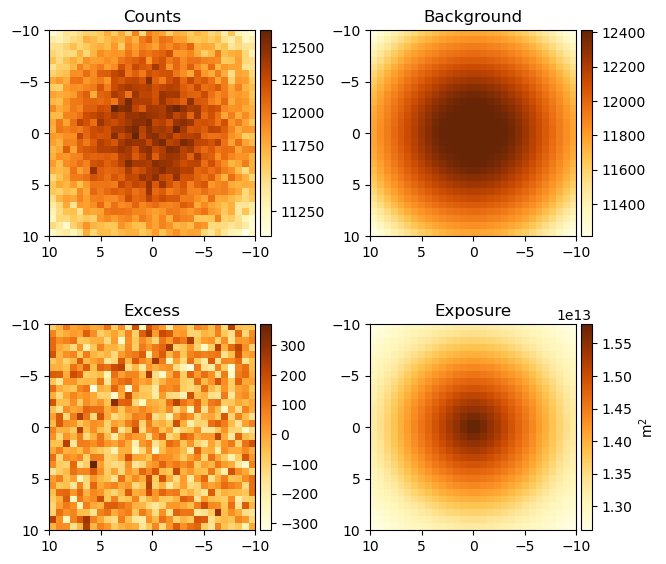

In [939]:
fig_peek, axs = plt.subplots(2,2, figsize=(7,7))

img_1 = axs[0,0].imshow(
    np.sum(dataset_mc.counts.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr',
)
axs[0,0].set_title('Counts')
divider = make_axes_locatable(axs[0,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_1 = fig_peek.colorbar(img_1, cax=cax, orientation='vertical')

img_2 = axs[0,1].imshow(
    np.sum(dataset_mc.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[0,1].set_title('Background')
divider = make_axes_locatable(axs[0,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_2 = fig_peek.colorbar(img_2, cax=cax, orientation='vertical')

img_3 = axs[1,0].imshow(
    np.sum(dataset_mc.counts.data, axis=0) - np.sum(dataset_mc.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,0].set_title('Excess')
divider = make_axes_locatable(axs[1,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_3 = fig_peek.colorbar(img_3, cax=cax, orientation='vertical')

img_4 = axs[1,1].imshow(
    np.sum(dataset_mc.exposure.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,1].set_title('Exposure')

divider = make_axes_locatable(axs[1,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_4 = fig_peek.colorbar(img_4, cax=cax, orientation='vertical')
cbar_4.ax.set_ylabel(r'm$^2$')

fig_peek.subplots_adjust(wspace=0.45, hspace=0.2)

plt.plot()

[]

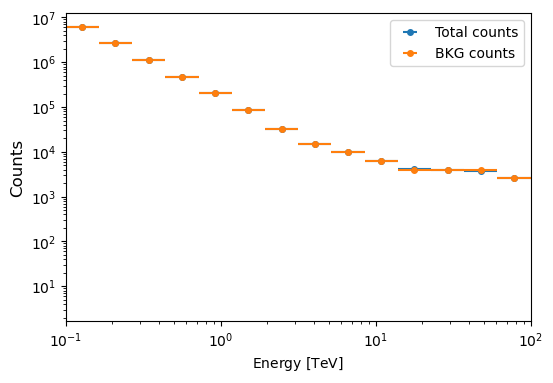

In [940]:
# Let's check the spectrum and the different contributions
spec, axs = plt.subplots(1, 1, figsize=(6, 4))
dataset_mc.counts.get_spectrum().plot(label='Total counts')
dataset_mc.npred_background().get_spectrum().plot(label='BKG counts')

axs.set_ylabel('Counts', fontsize=12)
axs.legend()
plt.plot()

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encou

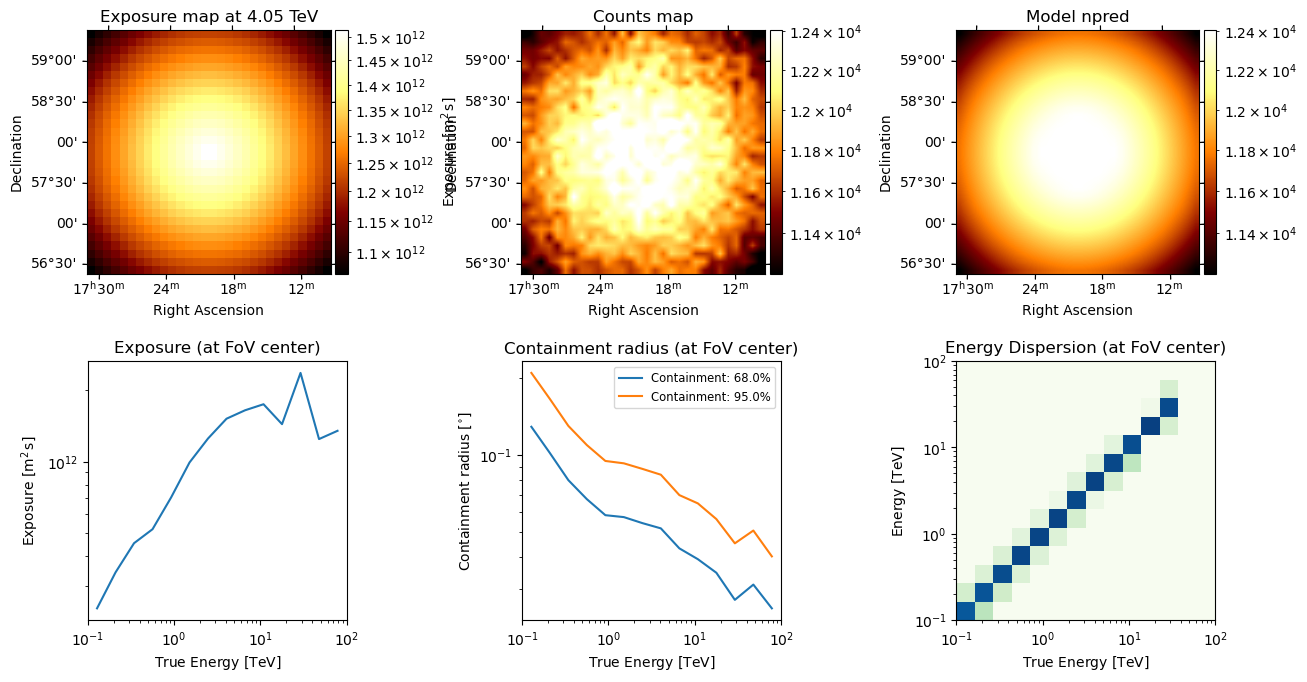

In [941]:
dataset_mc.peek()

### 3. No Signal: From Dataset to Upper Limits

The fit confirmed **TS ≈ 0**: the data are fully consistent with 
background only. We did not detect a signal, but we can still place a 
**constraint** on the DM parameter of interest — we can exclude signal 
amplitudes large enough to be inconsistent with what we observed.

---

#### The Profile Likelihood

We use the **profile likelihood** to derive the upper limit. The idea 
is simple: we scan `scale` over a grid of values and ask how much the 
likelihood degrades at each point:

$$\Delta \text{TS}(\text{scale}) = \text{stat}(\text{scale}) - 
\text{stat}(\hat{\text{scale}})$$

where $\hat{\text{scale}}$ is the best-fit value. By Wilks' theorem, 
the **95% CL upper limit** corresponds to the value of `scale` where:

$$\boxed{\Delta \text{TS} = 2.71}$$

---

In [ ]:
# ── Reset scale to a clean starting point ────────────────────────────────────
spectral_model.scale.value  = 1e-6
spectral_model.scale.min    = 0
spectral_model.scale.max    = None
spectral_model.scale.frozen = False

# ── Release background parameters ────────────────────────────────────────────
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].frozen = False
dataset_mc.models["dataset-simu-draco-bkg"].parameters["tilt"].frozen = False

scale_par = dataset_mc.models["draco-dm"].spectral_model.scale
scale_par.scan_values = np.logspace(-10, -2, 300)

print(f"Scan range:       {scale_par.scan_values.min():.1e}"
      f" — {scale_par.scan_values.max():.1e}")
print(f"Number of points: {len(scale_par.scan_values)}")
print("Running profile scan (this may take a few minutes)...")

# ── Run the profile likelihood ────────────────────────────────────────────────
profile = fit.stat_profile(
    datasets=dataset_mc,
    parameter=scale_par,
    reoptimize=True,    # re-optimize background at each scan point
)

print("Profile scan completed ✓")

Scan range:       1.0e-10 — 1.0e-02
Number of points: 300
Running profile scan (this may take a few minutes)...


In [960]:
# ── Extract arrays ────────────────────────────────────────────────────────────
scale_scan = profile["draco-dm.spectral.scale_scan"]
delta_ts   = profile["stat_scan"] - profile["stat_scan"].min()

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"Minimum ΔTS: {delta_ts.min():.4f}  (should be ≈ 0)")
print(f"Maximum ΔTS: {delta_ts.max():.2f}   (must be > 2.71 to find UL)")

Minimum ΔTS: 0.0000  (should be ≈ 0)
Maximum ΔTS: 169952796378.65   (must be > 2.71 to find UL)


We see that the maximum ΔTS is bigger than 2.71, so we can compute the upper limit of the scale and convert it into a physical value for our study case. If this wasn't the case, we must reconsiderer the configuration for the scan (i.e. scan_max...) and run again.

In [ ]:
# ── Find scale_ul: crossing at ΔTS = 2.71 on the right branch ────────────────
# We interpolate only on the right side of the minimum (upper limit side)
idx_min  = np.argmin(delta_ts)
scale_ul = np.interp(2.71,
                     delta_ts[idx_min:],
                     scale_scan[idx_min:])

# ── Convert to physical limits ────────────────────────────────────────────────

# Decay: scale = τ_ref / τ_χ  →  τ_χ > τ_ref / scale_ul
tau_ref         = spectral_model.LIFETIME_AGE_OF_UNIVERSE   # ~4.3e17 s
tau_lower_limit = tau_ref / scale_ul

#Here you have the example for the case of annihilation, but we are not going to use it in this tutorial since we are working with decay.
# Annihilation (for reference): scale = <σv> / <σv>_ref  →  <σv> < scale_ul × <σv>_ref
# sigma_v_ref = 3e-26 * u.Unit("cm3 s-1")
# sigma_v_ul  = scale_ul * sigma_v_ref

print(f"  DM mass:    {massDM}")
print(f"  Channel:    {channel}")
print(f"  Livetime:   {livetime}")
print(f"  scale UL (95% CL):          {scale_ul:.3e}")


  DM mass:    10.0 TeV
  Channel:    b
  Livetime:   500.0 h
  scale UL (95% CL):          1.000e-02


Now we plot the profile likelihood **interpretar**

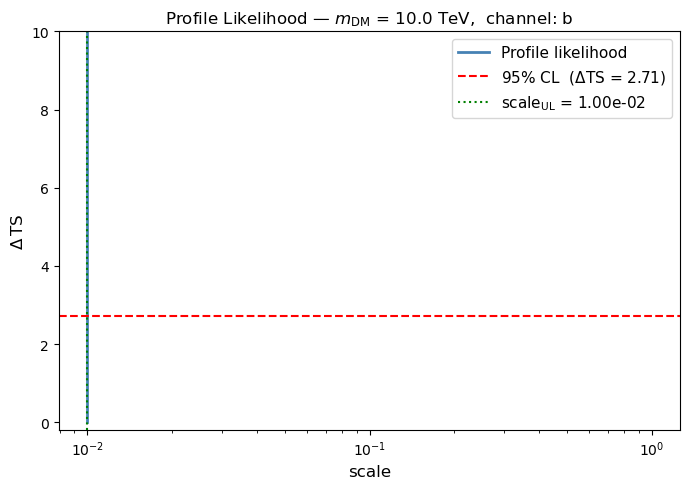

In [962]:
fig, ax = plt.subplots(figsize=(7, 5))

# ── Profile curve ─────────────────────────────────────────────────────────────
ax.plot(scale_scan, delta_ts,
        color="steelblue", linewidth=2,
        label="Profile likelihood")

# ── 95% CL threshold ──────────────────────────────────────────────────────────
ax.axhline(2.71,
           color="red", linestyle="--", linewidth=1.5,
           label=r"95% CL  ($\Delta$TS = 2.71)")

# ── Upper limit marker ────────────────────────────────────────────────────────
ax.axvline(scale_ul,
           color="green", linestyle=":", linewidth=1.5,
           label=f"scale$_{{\\rm UL}}$ = {scale_ul:.2e}")

ax.set_xscale("log")
ax.set_xlabel("scale", fontsize=12)
ax.set_ylabel(r"$\Delta\,\mathrm{TS}$", fontsize=12)
ax.set_ylim(-0.2, 10)
ax.legend(fontsize=11)
ax.set_title(
    rf"Profile Likelihood — $m_{{\rm DM}}$ = {massDM},  "
    rf"channel: {channel}",
    fontsize=12
)
plt.tight_layout()
plt.show()

### Over many masses

Over many masses

In [ ]:
# Mass range we want to scan. You can adjust it as needed. For example, if you want to explore lower masses, you can add 0.1, 0.3, 0.5 TeV, etc.
masses = np.arange(200, 1000, 500) * u.GeV

# Scan grid (adjust if needed per mass)
scale_values = np.logspace(-10, -2, 100)

# Output containers
results = {
    "mass"     : [],
    "scale_ul" : [],
    "scale_ll"   : []   # lower limit on scale
}

fit = Fit()

print(f"Running exclusion curve over {len(masses)} masses...")

for mass in masses:

    # Update mass
    spectral_model.mass.quantity = mass
    print(f"  mass = {mass}  ...", end=" ")

    # Simulate background-only dataset
    spectral_model.scale.frozen = True
    spatial_model.lon_0.frozen  = True
    spatial_model.lat_0.frozen  = True

    bkg_model_m = FoVBackgroundModel(dataset_name=f"dataset-{mass.value:.0f}TeV")
    bkg_model_m.parameters["norm"].frozen = False
    bkg_model_m.parameters["tilt"].frozen = False

    dataset_m = dataset.copy(name=f"dataset-{mass.value:.0f}TeV")
    dataset_m.models = Models([
        SkyModel(spatial_model=spatial_model,
                 spectral_model=spectral_model,
                 name="draco-dm"),
        bkg_model_m
    ])

    # Fit background
    result_bkg = fit.run(datasets=[dataset_m])
    if not result_bkg.success:
        print(f"Background fit did not converge, it will be skipped, please check.")
        continue

    # Freeze background + free scale
    bkg_model_m.parameters["norm"].frozen = True
    bkg_model_m.parameters["tilt"].frozen = True

    spectral_model.scale.frozen = False
    spectral_model.scale.value  = 1e-7
    spectral_model.scale.min    = 0
    spectral_model.scale.max    = None

    display(dataset_m.models.parameters.to_table())
    # Profile scan
    scale_par_m = dataset_m.models["draco-dm"].spectral_model.scale
    scale_par_m.scan_values = scale_values

    profile_m  = fit.stat_profile(
        datasets=dataset_m,
        parameter=scale_par_m,
        reoptimize=False,
    )

    scale_scan_m = profile_m["draco-dm.spectral.scale_scan"]
    delta_ts_m   = profile_m["stat_scan"] - profile_m["stat_scan"].min()

    if delta_ts_m.max() < 2.71:
        print(f"Profile did not reach ΔTS=2.71, it will be skipped, please check.")
        continue

    # Extract scale_ul
    idx_min  = np.argmin(delta_ts_m)
    scale_ul = np.interp(2.71,
                         delta_ts_m[idx_min:],
                         scale_scan_m[idx_min:])

    # Convert to physical limits
    scale_ref  = spectral_model.LIFETIME_AGE_OF_UNIVERSE
    scale_ll   = scale_ref / scale_ul

    sigma_v_ref = 3e-26 * u.Unit("cm3 s-1")
    sigmav_ul   = scale_ul * sigma_v_ref

    # Store results ──────────────────────────────────────────────────────
    results["mass"].append(mass.to("TeV").value)
    results["scale_ul"].append(scale_ul)
    results["scale_ll"].append(scale_ll.value)

    print(f"scale_ul = {scale_ul:.12e}  |  scale_ll > {scale_ll:.10e}")

print("─" * 55)
print(f"Done. {len(results['mass'])} mass points computed.")

Running exclusion curve over 2 masses...
  mass = 200.0 GeV  ... 

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
,scale,1.0000e-07,,0.000e+00,0.000e+00,nan,False,,
,lon_0,2.6005e+02,deg,0.000e+00,nan,nan,True,,
,lat_0,5.7915e+01,deg,0.000e+00,-9.000e+01,9.000e+01,True,,
,tilt,1.2549e-03,,5.193e-04,nan,nan,True,,
,norm,9.9285e-01,,9.175e-04,nan,nan,True,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


scale_ul = 9.826041402959e-09  |  scale_ll > 4.3761264823e+25 s
  mass = 700.0 GeV  ... 

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
,scale,1.0000e-07,,0.000e+00,0.000e+00,nan,False,,
,lon_0,2.6005e+02,deg,0.000e+00,nan,nan,True,,
,lat_0,5.7915e+01,deg,0.000e+00,-9.000e+01,9.000e+01,True,,
,tilt,4.2715e-04,,5.175e-04,nan,nan,True,,
,norm,9.9816e-01,,9.191e-04,nan,nan,True,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


scale_ul = 6.092288066791e-09  |  scale_ll > 7.0581035448e+25 s
───────────────────────────────────────────────────────
Done. 2 mass points computed.


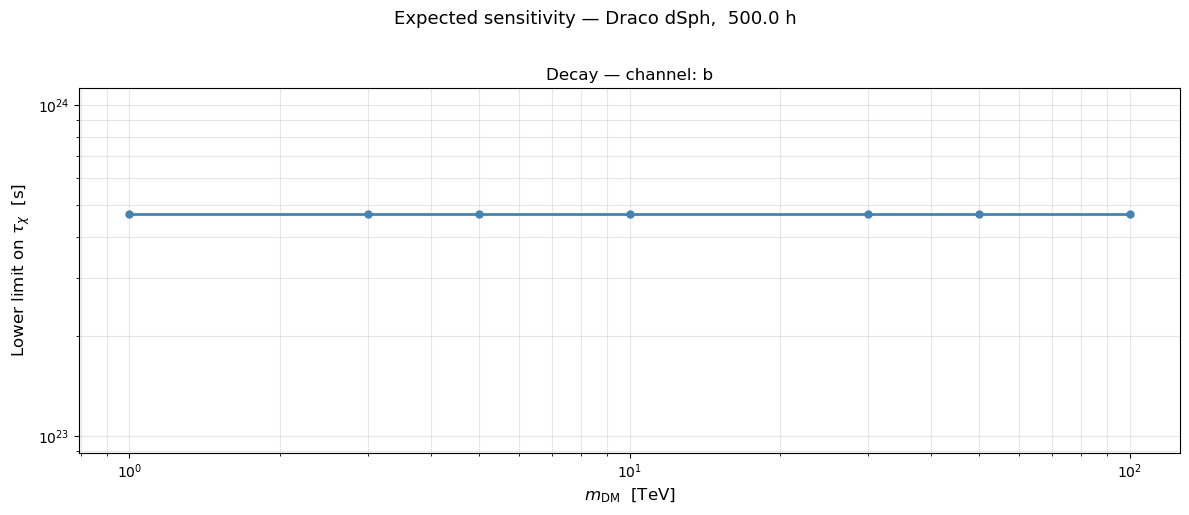

In [947]:
fig, ax = plt.subplots(1, figsize=(12, 5))

mass_arr    = np.array(results["mass"])
scale_arr   = np.array(results["scale_ll"])

# ── Decay: lower limit on scale ────────────────────────────────────────────────
ax.plot(mass_arr, scale_arr,
        color="steelblue", linewidth=2, marker="o", markersize=5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_{\rm DM}$  [TeV]", fontsize=12)
ax.set_ylabel(r"Lower limit on $\tau_\chi$  [s]", fontsize=12)
ax.set_title(rf"Decay — channel: {channel}", fontsize=12)
ax.grid(True, which="both", alpha=0.3)

plt.suptitle(rf"Expected sensitivity — Draco dSph,  {livetime}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()